# EDA

In [0]:
# Core Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [0]:
df = spark.read.format("delta").load("/Volumes/workspace/default/ai-enhanced_project/Cars_Datasets_2025_cleaned_delta")
df = df.toPandas()

In [0]:
%skip
df = spark.read.format("delta").load("/Volumes/workspace/default/ai-enhanced_project/Cars_Datasets_2025_FE_delta")
df = df.toPandas()

print(f"Starting shape: {df.shape}")
df.head()

In [0]:
# Basic info
print("DataFrame Info:")
df.info()

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1043 entries, 0 to 1042
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   company_names          1043 non-null   object 
 1   cars_names             1043 non-null   object 
 2   Engines                1043 non-null   object 
 3   cc_battery_capacity    1043 non-null   int64  
 4   HorsePower             1043 non-null   int64  
 5   total_speed            1043 non-null   int64  
 6   performance_0_100_kmh  1043 non-null   float64
 7   cars_prices            1043 non-null   int64  
 8   fuel_types             1043 non-null   object 
 9   Seats                  1043 non-null   int64  
 10  Torque                 1043 non-null   int64  
dtypes: float64(1), int64(6), object(4)
memory usage: 89.8+ KB


In [0]:
df.describe()

,cc_battery_capacity,HorsePower,total_speed,performance_0_100_kmh,cars_prices,Seats,Torque
count,1043.000000,1043.000000,1043.000000,1043.000000,1043.000000,1043.000000,1043.000000
mean,2412.918504,244.699904,203.905081,8.174497,43970.202301,5.078619,378.058485
std,1677.669171,120.527293,38.471711,3.091334,24742.009788,1.360801,237.650164
min,1.000000,26.000000,80.000000,2.500000,4000.000000,2.000000,45.000000
25%,1499.000000,145.500000,180.000000,6.100000,26375.000000,5.000000,245.000000
50%,1998.000000,215.000000,200.000000,7.500000,38000.000000,5.000000,350.000000
75%,2995.000000,325.000000,230.000000,9.800000,55000.000000,5.000000,472.500000
max,13000.000000,603.000000,320.000000,35.000000,132750.000000,20.000000,2600.000000


In [0]:
# Summary statistics
print("\nSummary Statistics:")
print(df.describe(include='all'))


Summary Statistics:
       company_names cars_names Engines  ...  fuel_types        Seats       Torque
count           1043       1043    1043  ...        1043  1043.000000  1043.000000
unique            25       1032     332  ...           5          NaN          NaN
top           NISSAN  Macan GTS      I4  ...      Petrol          NaN          NaN
freq             151          2      64  ...         761          NaN          NaN
mean             NaN        NaN     NaN  ...         NaN     5.078619   378.058485
std              NaN        NaN     NaN  ...         NaN     1.360801   237.650164
min              NaN        NaN     NaN  ...         NaN     2.000000    45.000000
25%              NaN        NaN     NaN  ...         NaN     5.000000   245.000000
50%              NaN        NaN     NaN  ...         NaN     5.000000   350.000000
75%              NaN        NaN     NaN  ...         NaN     5.000000   472.500000
max              NaN        NaN     NaN  ...         NaN    20.000

In [0]:
# Distribution of categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"\nValue counts for {col}:")
    print(df[col].value_counts().head(10))


Value counts for company_names:
company_names
NISSAN        151
VOLKSWAGEN    106
MAZDA          85
KIA            71
MITSUBISHI     60
PORSCHE        59
CHEVROLET      56
PEUGEOT        52
FORD           51
GMC            51
Name: count, dtype: int64

Value counts for cars_names:
cars_names
Macan GTS                    2
200SX                        2
Malibu Premier               2
NX Coupe                     2
Panamera Platinum Edition    2
911 Carrera 4                2
Macan S                      2
Macan T                      2
Polo BlueMotion              2
MIRAI                        2
Name: count, dtype: int64

Value counts for Engines:
Engines
I4                      64
V6                      39
Inline-4                38
2.0L Inline-4           20
1.6L Inline-4           19
Electric Motor          18
Dual Electric Motors    17
5.6L V8                 17
6.2L V8 Gasoline        15
5.3L V8 Gasoline        15
Name: count, dtype: int64

Value counts for fuel_types:
fuel_type

separate on categorical or numerical

In [0]:
cat_df = df.select_dtypes(include=['object'])
num_df = df.select_dtypes(include=['int64', 'float64'])

cat_col = cat_df.columns.tolist()
num_col = num_df.columns.tolist()

## Basic overview

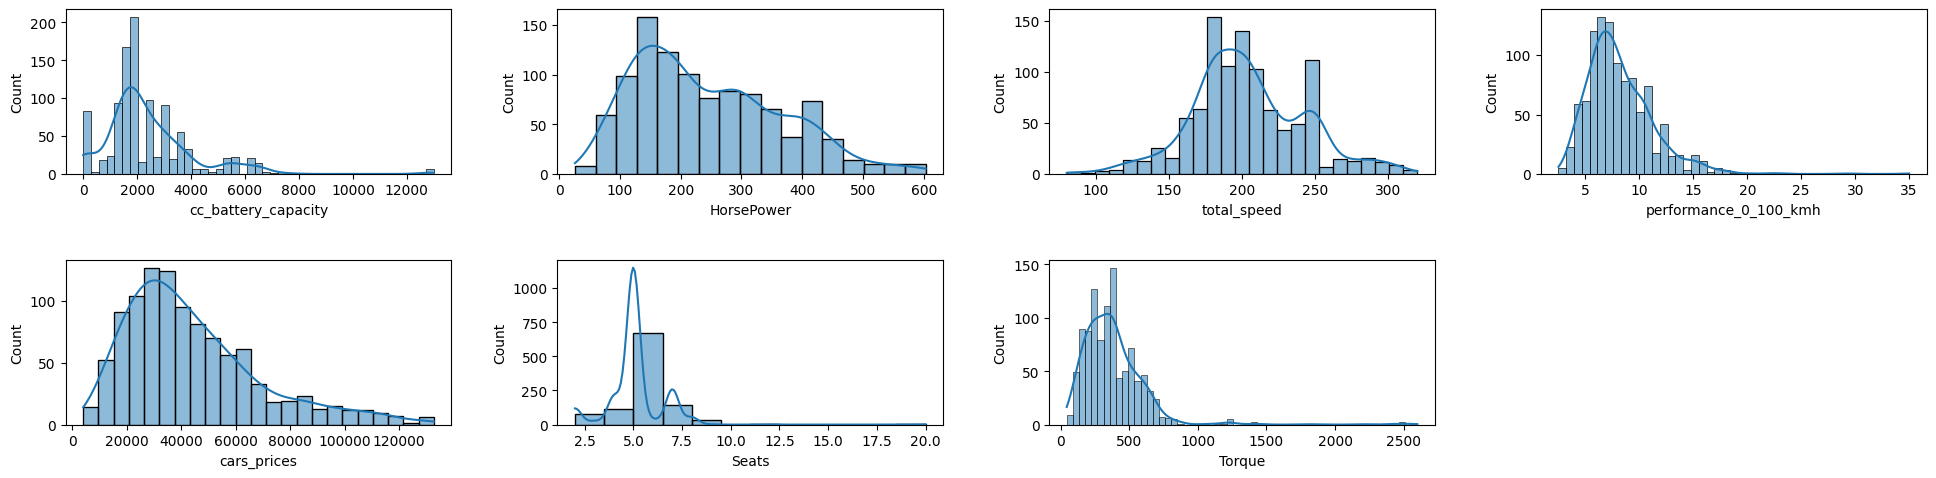

In [0]:
plt.figure(figsize=(20,10))

for index, col in enumerate(num_col):
    plt.subplot(4, 4, index+1)
    sns.histplot(data=df, x=col, kde=True)
plt.tight_layout(pad=3.0)
plt.show()

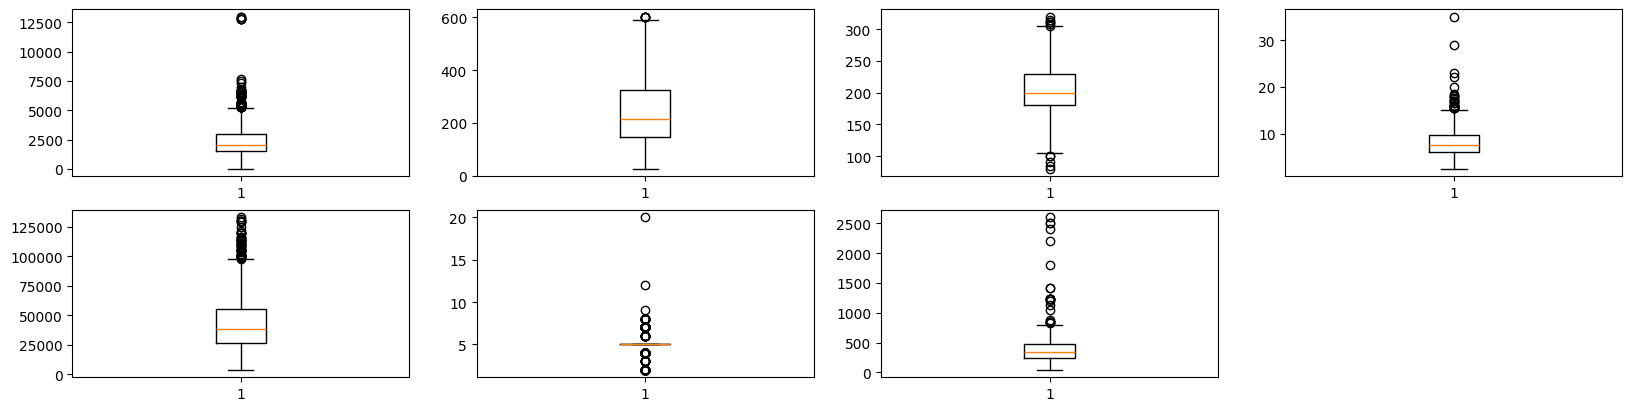

In [0]:
plt.figure(figsize=(20,10))

for index,col in enumerate(num_col):
    plt.subplot(4,4,index+1)
    plt.boxplot(df[col])
plt.show()

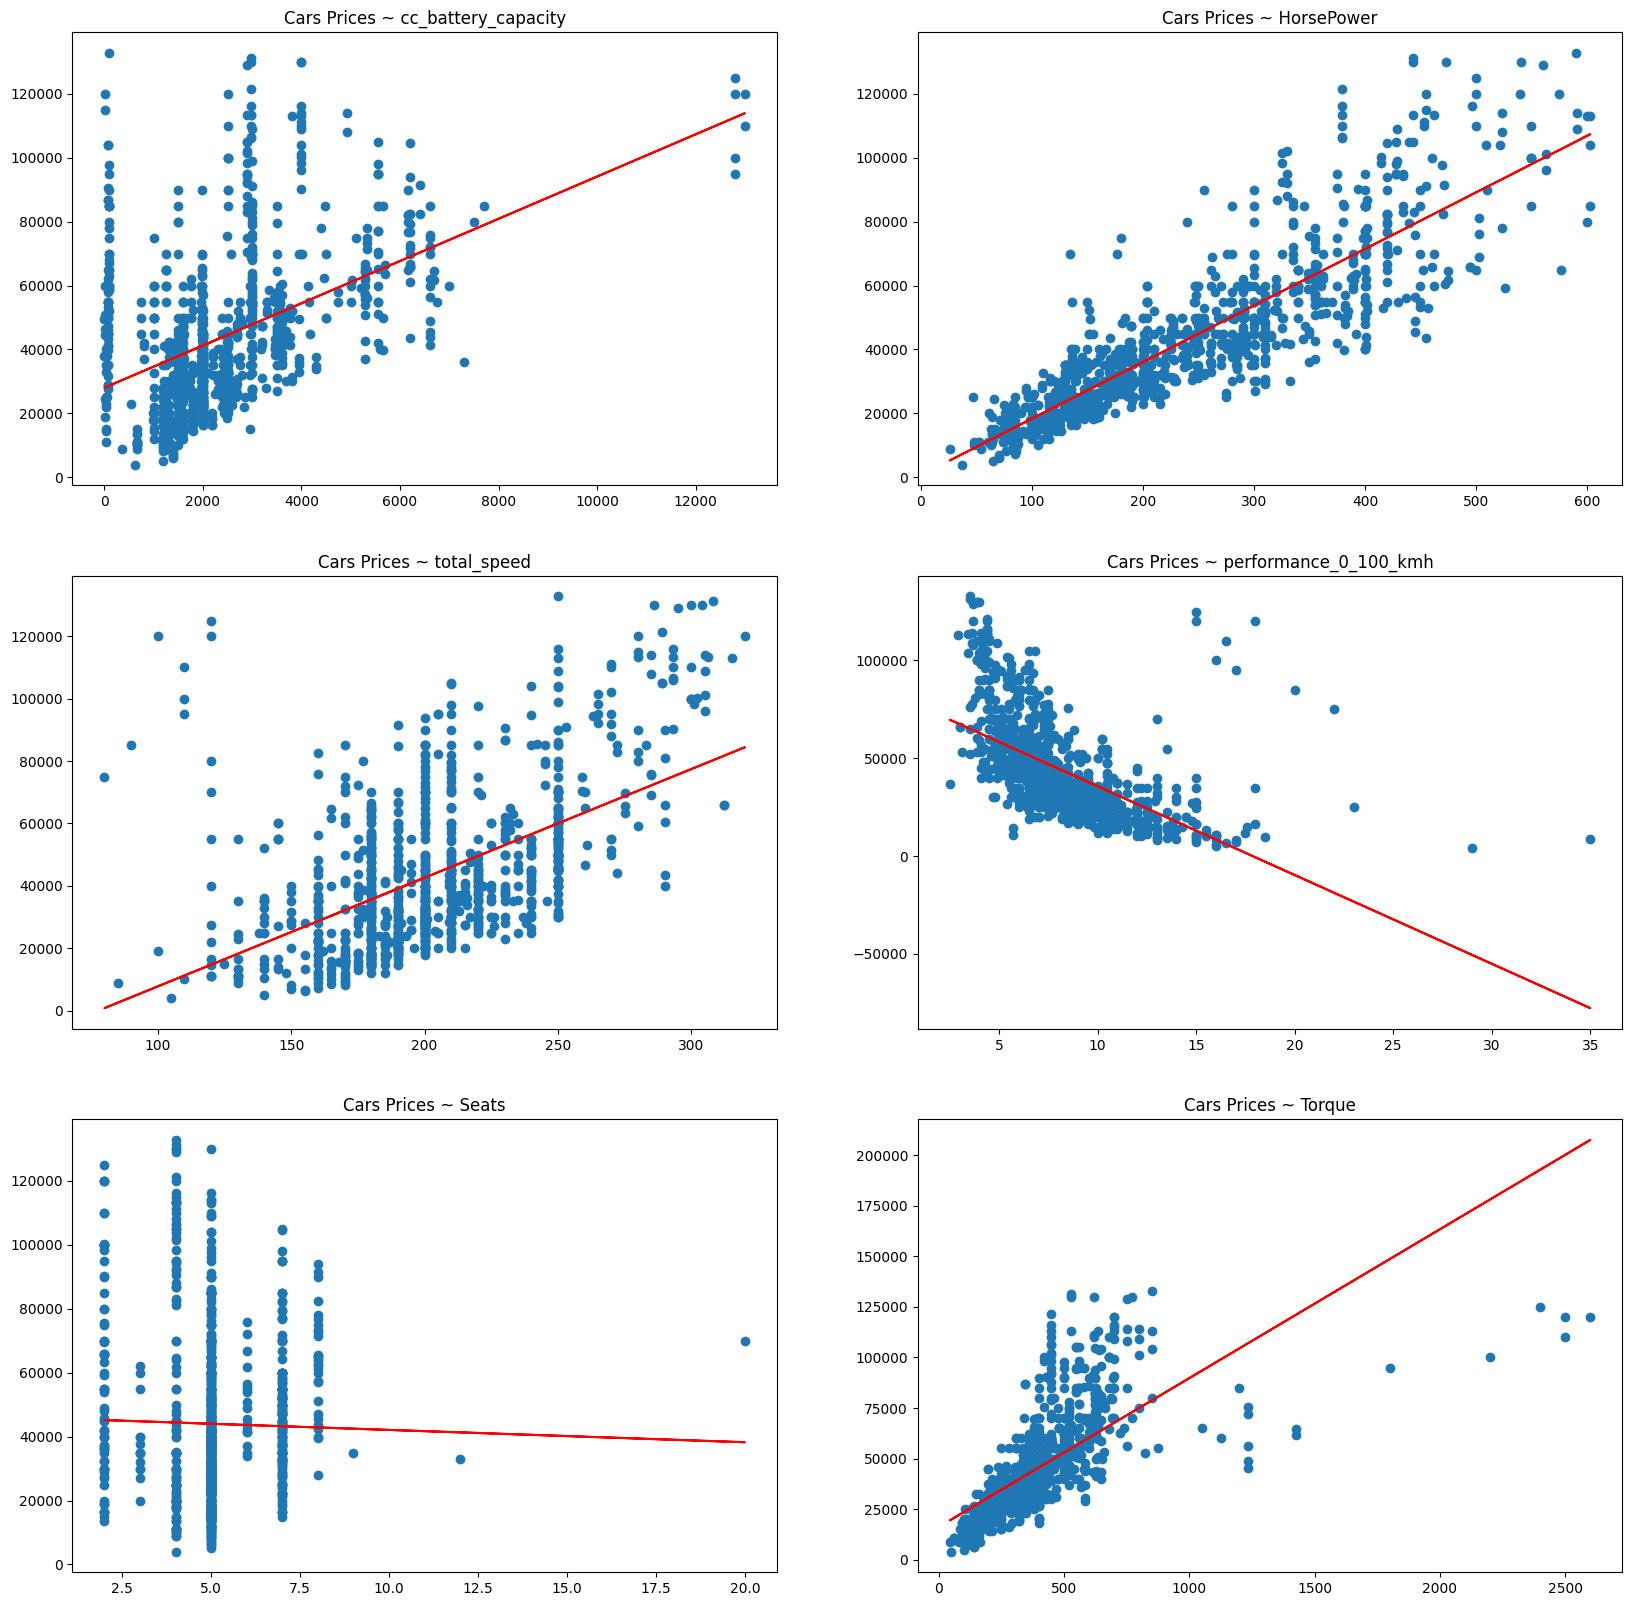

In [0]:
plt.figure(figsize=(20,20))

plot_col = num_col
plot_col.remove('cars_prices')
for index,col in enumerate(plot_col):
    slope, intercept = np.polyfit(df[col], df['cars_prices'], deg=1)
    line = slope*df[col] + intercept

    plt.subplot(3,2,index+1)
    plt.plot(df[col], line, color='red')
    plt.scatter(df[col], df['cars_prices'])
    plt.title(f"Cars Prices ~ {col}")
plt.show()

## More indepth

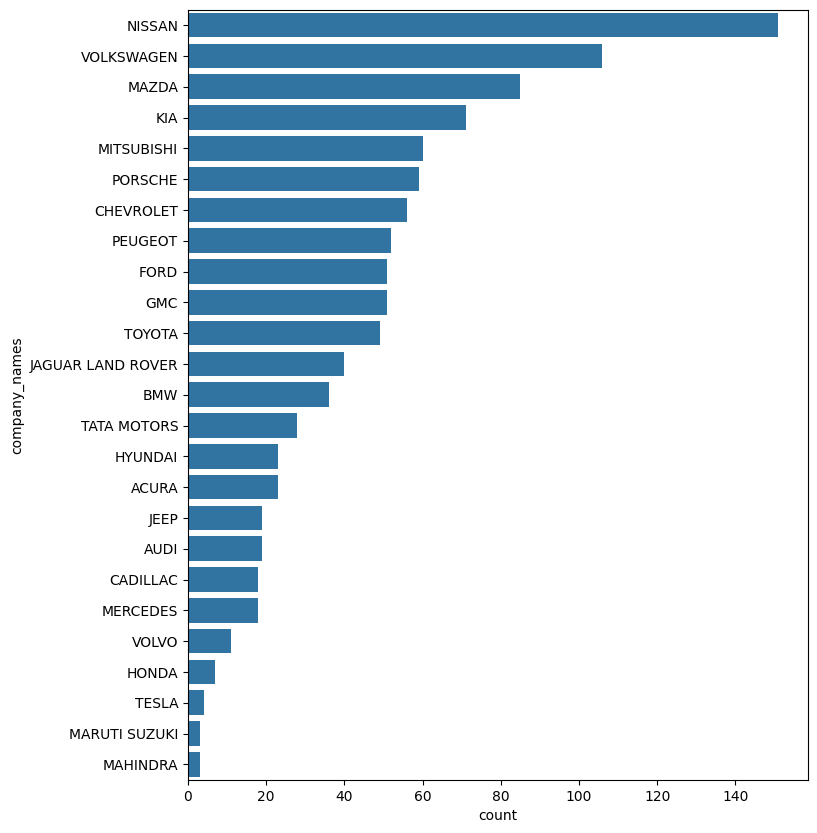

In [0]:
plt.figure(figsize=(8,10))
order = df['company_names'].value_counts().index
sns.countplot(data=df, y='company_names', order=order)
plt.show()

/home/spark-e292ad72-dc00-416f-b7d8-b2/.ipykernel/2025/command-5379756859377424-1062294533:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_brands.index, y=top_brands.values, palette='Set3')


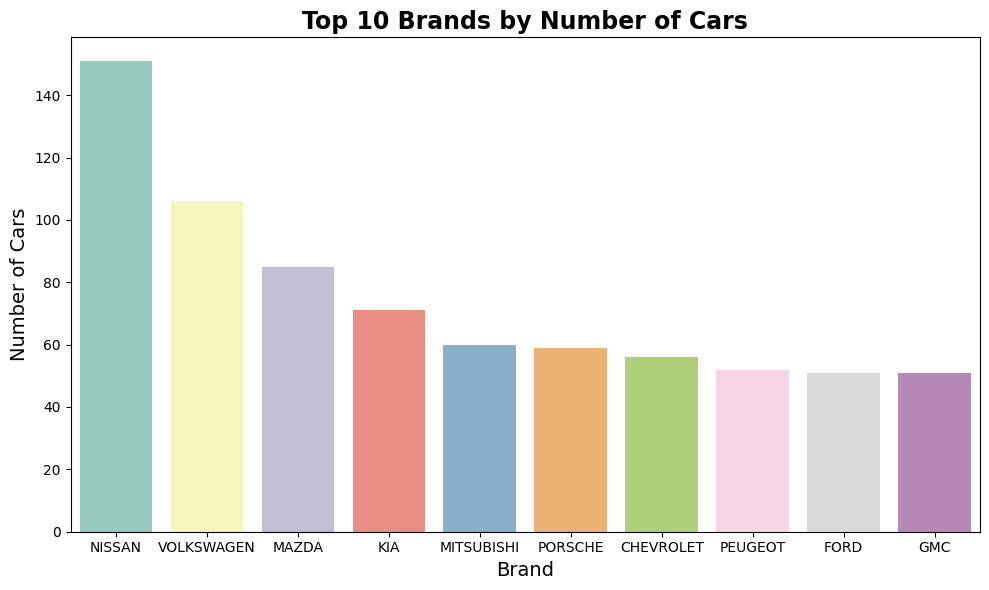

In [0]:
top_brands = df['company_names'].value_counts().head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=top_brands.index, y=top_brands.values, palette='Set3')
plt.title('Top 10 Brands by Number of Cars', fontsize=17, fontweight='bold')
plt.xlabel('Brand', fontsize=14)
plt.ylabel('Number of Cars', fontsize=14)
plt.tight_layout()
plt.show() 

/home/spark-e292ad72-dc00-416f-b7d8-b2/.ipykernel/2025/command-5379756859377425-1877740832:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='fuel_types', y='performance_0_100_kmh', data=df[df['fuel_types'].isin(top_fuels)], palette='pastel')


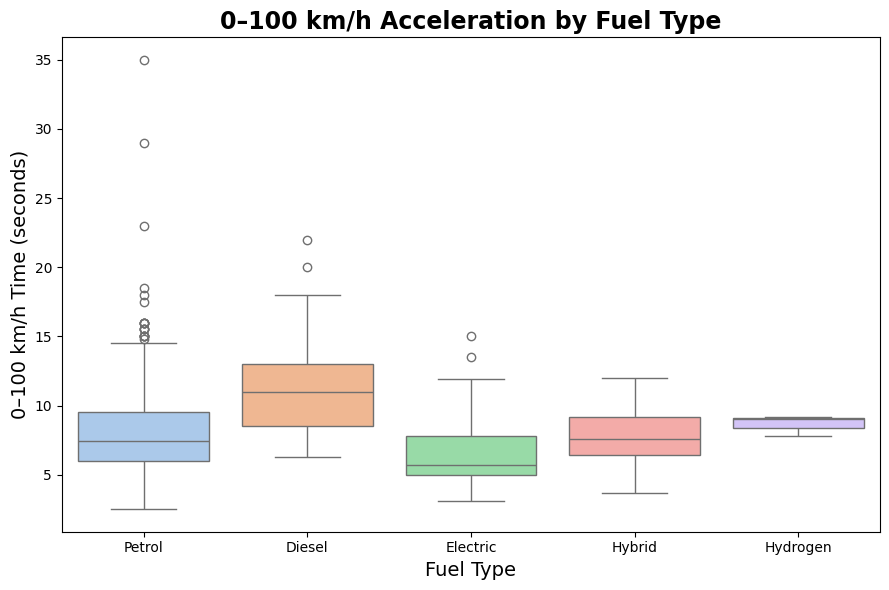

In [0]:
top_fuels = df['fuel_types'].value_counts().head(5).index
plt.figure(figsize=(9,6))
sns.boxplot(x='fuel_types', y='performance_0_100_kmh', data=df[df['fuel_types'].isin(top_fuels)], palette='pastel')
plt.title('0–100 km/h Acceleration by Fuel Type', fontsize=17, fontweight='bold')
plt.xlabel('Fuel Type', fontsize=14)
plt.ylabel('0–100 km/h Time (seconds)', fontsize=14)
plt.tight_layout()
plt.show() 

/home/spark-e292ad72-dc00-416f-b7d8-b2/.ipykernel/2025/command-5379756859377426-2708658981:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='company_names', y='HorsePower', data=df[df['company_names'].isin(top6brands)], palette='Set2')


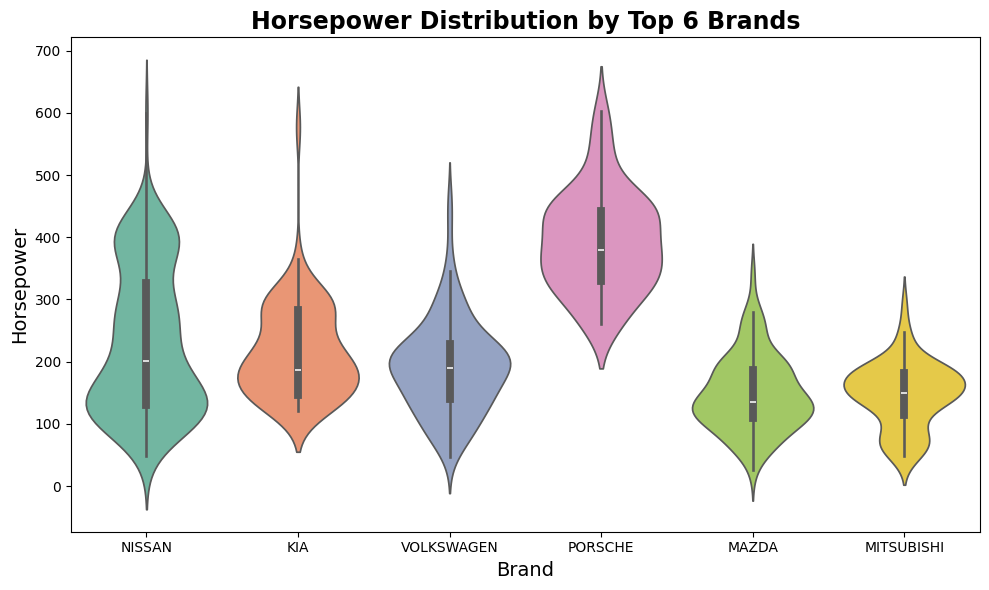

In [0]:
top6brands = df['company_names'].value_counts().head(6).index
plt.figure(figsize=(10,6))
sns.violinplot(x='company_names', y='HorsePower', data=df[df['company_names'].isin(top6brands)], palette='Set2')
plt.title('Horsepower Distribution by Top 6 Brands', fontsize=17, fontweight='bold')
plt.xlabel('Brand', fontsize=14)
plt.ylabel('Horsepower', fontsize=14)
plt.tight_layout()
plt.show() 

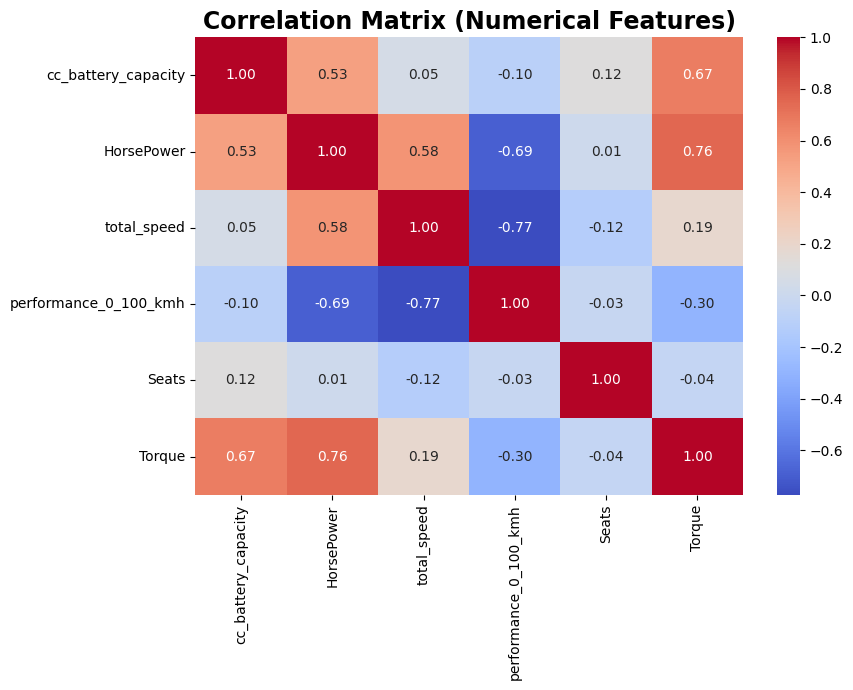

In [0]:
plt.figure(figsize=(9,7))
corr = df[['cc_battery_capacity', 'HorsePower', 'total_speed', 'performance_0_100_kmh', 'Seats', 'Torque']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix (Numerical Features)', fontsize=17, fontweight='bold')
plt.tight_layout()
plt.show() 

<Axes: xlabel='cars_prices', ylabel='HorsePower'>

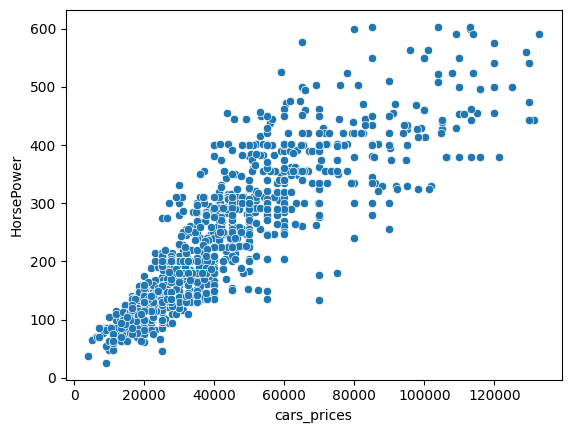

In [0]:
sns.scatterplot(data = df,x = 'cars_prices',y = 'HorsePower')

In [0]:
%skip
# Preprocessing for linear regression

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Features and target
X = df.drop('Cars Prices', axis=1)
y = df['Cars Prices']

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit and transform training data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)